<a href="https://colab.research.google.com/github/Asifr001/icu-nlr-data-pipeline/blob/main/Neutrophils_Lymphocytes_Ratio_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
ICU CBC dataset
Merge WBC / Neutrophils / Lymphocytes by draw, validate, calculate NLR.
"""

import pandas as pd
import numpy as np

In [ ]:
# ----------------------------------------------------------------------
# 0. SETUP
# ----------------------------------------------------------------------
INPUT_PATH = "wbc_nlr_redacted.xlsx"
OUTPUT_PATH = "NLR_merged_validated.xlsx"


df = pd.read_excel(INPUT_PATH)
print(f"Loaded {len(df):,} rows, {df['SubjectID'].nunique():,} subjects")


Loaded 65,139 rows, 907 subjects


In [ ]:
# Show column names
print(df.columns)

Index(['SubjectID', 'Asc', 'Battery', 'Uniform_Name', 'test', 'Result',
       'units', 'GK_proposedName', 'labdate_mod', 'labreceiveddate_mod'],
      dtype='object')


In [ ]:
# ----------------------------------------------------------------------
# 1. CLEAN
# ----------------------------------------------------------------------
# Drop the always-empty helper column
df = df.drop(columns=["Unnamed: 8"], errors="ignore")

# Result has numeric lab values mixed with text flags (UAVL, QNS, CLOT, COVPUI, etc.)
# Keep the raw value for reference, coerce a numeric version for analysis
df["Result_raw"] = df["Result"]
df["Result_numeric"] = pd.to_numeric(df["Result"], errors="coerce")

n_flagged = df["Result_numeric"].isna().sum() - df["Result"].isna().sum()
print(f"{n_flagged:,} rows had non-numeric lab flags (e.g. UAVL/QNS/CLOT) -> set to NaN")

# Standardize unit label (all observed variants represent the same scale, 10^9/L,
# just written differently by different lab instruments/systems).
df["units_clean"] = df["units"].astype(str).str.strip().str.upper()

# Sanity check: confirm value ranges are consistent across unit-label variants.
# If any unit group's median is ~1000x off from the rest, it signals a real
# scale mismatch (not just a labeling difference) that needs separate handling.
unit_check = (
    df.dropna(subset=["Result_numeric"])
    .groupby("units_clean")["Result_numeric"]
    .median()
    .sort_values()
)
print("\nMedian result by unit label (check for ~1000x outliers):")
print(unit_check)

# Deduplicate exact duplicate rows (same subject/Asc/test/result/time)
before = len(df)
df = df.drop_duplicates(subset=["SubjectID", "Asc", "GK_proposedName", "Result_raw", "labdate_mod"])
print(f"\nDropped {before - len(df):,} exact duplicate rows")

1,881 rows had non-numeric lab flags (e.g. UAVL/QNS/CLOT) -> set to NaN

Median result by unit label (check for ~1000x outliers):
units_clean
               1.10
/CMM           1.55
10*9/L         5.30
X10E*3         5.30
TH/MM3         6.10
X10E3/UL       6.70
X1OE+09/L      6.70
X10E+09/L      7.10
TH/UL          7.70
K/UL           7.90
X10E+03/UL    10.20
10E+9/L       11.50
TH/CUMM       12.40
Name: Result_numeric, dtype: float64

Dropped 9,286 exact duplicate rows


In [ ]:
# ----------------------------------------------------------------------
# 2. PIVOT: making it from long to wide, one row per blood draw
# ----------------------------------------------------------------------
# Keep one labdate per (SubjectID, Asc) group -- it's consistent within a draw
labdate_lookup = (
    df.groupby(["SubjectID", "Asc"])["labdate_mod"].min().rename("labdate")
)

# Pivot proposedName -> columns of Result_numeric
# If duplicate (subject, Asc, test) rows survived with differing values, took the mean
wide = (
    df.pivot_table(
        index=["SubjectID", "Asc"],
        columns="proposedName",
        values="Result_numeric",
        aggfunc="mean",
    )
    .reset_index()
)

wide = wide.merge(labdate_lookup, on=["SubjectID", "Asc"], how="left")

wide = wide.rename(columns={
    "wbc": "WBC",
    "neutrophils_abs": "ANC",
    "lymphocytes_abs": "ALC",
})

# Ensure all three columns exist even if a category was entirely absent
for col in ["WBC", "ANC", "ALC"]:
    if col not in wide.columns:
        wide[col] = np.nan

wide = wide[["SubjectID", "Asc", "labdate", "WBC", "ANC", "ALC"]]

print(f"\nPivoted to {len(wide):,} draws (rows)")
n_complete = wide.dropna(subset=["WBC", "ANC", "ALC"]).shape[0]
print(f"{n_complete:,} draws ({n_complete/len(wide)*100:.1f}%) have WBC, ANC, and ALC all present")


Pivoted to 20,917 draws (rows)
16,664 draws (79.7%) have WBC, ANC, and ALC all present


In [ ]:
# ----------------------------------------------------------------------
# 3. VALIDATE: ANC + ALC should be <= WBC (allow small tolerance for rounding)
# ----------------------------------------------------------------------
TOLERANCE = 0.05  # 5% tolerance above WBC before flagging as failed

wide["sum_ANC_ALC"] = wide["ANC"] + wide["ALC"]
wide["validation_pass"] = np.where(
    wide[["WBC", "ANC", "ALC"]].isna().any(axis=1),
    np.nan,  # can't validate incomplete draws
    wide["sum_ANC_ALC"] <= wide["WBC"] * (1 + TOLERANCE),
)

n_valid = (wide["validation_pass"] == True).sum()
n_invalid = (wide["validation_pass"] == False).sum()
n_incomplete = wide["validation_pass"].isna().sum()
print(f"\nValidation: {n_valid:,} pass, {n_invalid:,} fail (sum > WBC + {TOLERANCE:.0%}), "
      f"{n_incomplete:,} incomplete (can't check)")


Validation: 16,656 pass, 8 fail (sum > WBC + 5%), 4,253 incomplete (can't check)


In [ ]:
# ----------------------------------------------------------------------
# 4. CALCULATE NLR
# ----------------------------------------------------------------------
# NLR undefined when ALC is 0 or missing; only calculate on validated draws
wide["NLR"] = np.where(
    (wide["validation_pass"] == True) & (wide["ALC"] > 0),
    wide["ANC"] / wide["ALC"],
    np.nan,
)

n_nlr = wide["NLR"].notna().sum()
print(f"NLR calculated for {n_nlr:,} draws ({n_nlr/len(wide)*100:.1f}% of all draws)")

NLR calculated for 16,383 draws (78.3% of all draws)


In [ ]:
# ----------------------------------------------------------------------
# 5. SAVE
# ----------------------------------------------------------------------
wide_sorted = wide.sort_values(["SubjectID", "labdate"]).reset_index(drop=True)
wide_sorted.to_excel(OUTPUT_PATH, sheet_name="NLR_merged", index=False)
print(f"\nSaved merged/validated table to: {OUTPUT_PATH}")
print(f"Final table shape: {wide_sorted.shape}")


Saved merged/validated table to: NLR_merged_validated.xlsx
Final table shape: (20917, 9)


# **NLR - Visualization**

In [ ]:
"""
ICU CBC dataset - Descriptive statistics & visualization

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


In [ ]:
# ----------------------------------------------------------------------
# 0. SETUP
# ----------------------------------------------------------------------
INPUT_PATH = "NLR_merged_validated.xlsx"

df = pd.read_excel(INPUT_PATH)
df["labdate"] = pd.to_datetime(df["labdate"])

# Day-in-series index per patient (proxy for ICU day; true admission date
# isn't in this extract, so day 0 = each patient's first available draw here)
df = df.sort_values(["SubjectID", "labdate"])
df["day_index"] = (
    df.groupby("SubjectID")["labdate"]
    .transform(lambda x: (x - x.min()).dt.total_seconds() / 86400)
)


In [ ]:
# Ensure the column exists
if 'SubjectID' in df.columns:
    # Calculate the number of unique SubjectID values
    unique_count = df['SubjectID'].nunique()
    print(f"The number of unique 'SubjectID's is: {unique_count}")
else:
    print("The column 'SubjectID' was not found in the file.")

The number of unique 'SubjectID's is: 907


In [ ]:
# ----------------------------------------------------------------------
# 1. DESCRIPTIVE STATISTICS
# ----------------------------------------------------------------------
print("=" * 60)
print("SAMPLE OVERVIEW")
print("=" * 60)
n_patients = df["SubjectID"].nunique()
n_draws = len(df)
draws_per_patient = df.groupby("SubjectID").size()

print(f"Patients: {n_patients:,}")
print(f"Total draws: {n_draws:,}")
print(f"Draws per patient - median: {draws_per_patient.median():.0f}, "
      f"IQR: {draws_per_patient.quantile(.25):.0f}-{draws_per_patient.quantile(.75):.0f}, "
      f"range: {draws_per_patient.min()}-{draws_per_patient.max()}")

print("\n" + "=" * 60)
print("VALIDATION / COMPLETENESS SUMMARY")
print("=" * 60)
n_complete = df.dropna(subset=["WBC", "ANC", "ALC"]).shape[0]
n_pass = (df["validation_pass"] == 1).sum()
n_fail = (df["validation_pass"] == 0).sum()
n_incomplete = df["validation_pass"].isna().sum()
print(f"Draws with WBC+ANC+ALC all present: {n_complete:,} ({n_complete/n_draws*100:.1f}%)")
print(f"  -> passed validation (ANC+ALC<=WBC, 5% tol): {n_pass:,} ({n_pass/n_complete*100:.1f}% of complete)")
print(f"  -> failed validation: {n_fail:,}")
print(f"Incomplete draws (missing one of WBC/ANC/ALC): {n_incomplete:,}")

print("\n" + "=" * 60)
print("DISTRIBUTION SUMMARY (median [IQR], given right-skew typical of these labs)")
print("=" * 60)
for col in ["WBC", "ANC", "ALC", "NLR"]:
    s = df[col].dropna()
    print(f"{col:5s}: median={s.median():6.2f}  IQR={s.quantile(.25):6.2f}-{s.quantile(.75):6.2f}  "
          f"mean={s.mean():6.2f}  SD={s.std():6.2f}  range={s.min():.2f}-{s.max():.2f}  n={len(s):,}")

SAMPLE OVERVIEW
Patients: 907
Total draws: 20,917
Draws per patient - median: 16, IQR: 9-29, range: 1-328

VALIDATION / COMPLETENESS SUMMARY
Draws with WBC+ANC+ALC all present: 16,664 (79.7%)
  -> passed validation (ANC+ALC<=WBC, 5% tol): 16,656 (100.0% of complete)
  -> failed validation: 8
Incomplete draws (missing one of WBC/ANC/ALC): 4,253

DISTRIBUTION SUMMARY (median [IQR], given right-skew typical of these labs)
WBC  : median= 10.20  IQR=  7.20- 14.40  mean= 11.77  SD=  7.66  range=0.00-212.80  n=20,909
ANC  : median=  7.80  IQR=  5.11- 11.70  mean=  9.28  SD=  6.32  range=0.00-104.40  n=16,704
ALC  : median=  0.90  IQR=  0.50-  1.40  mean=  1.13  SD=  4.93  range=0.00-557.00  n=16,672
NLR  : median=  8.80  IQR=  4.75- 18.00  mean= 16.02  SD= 21.25  range=0.00-248.00  n=16,383


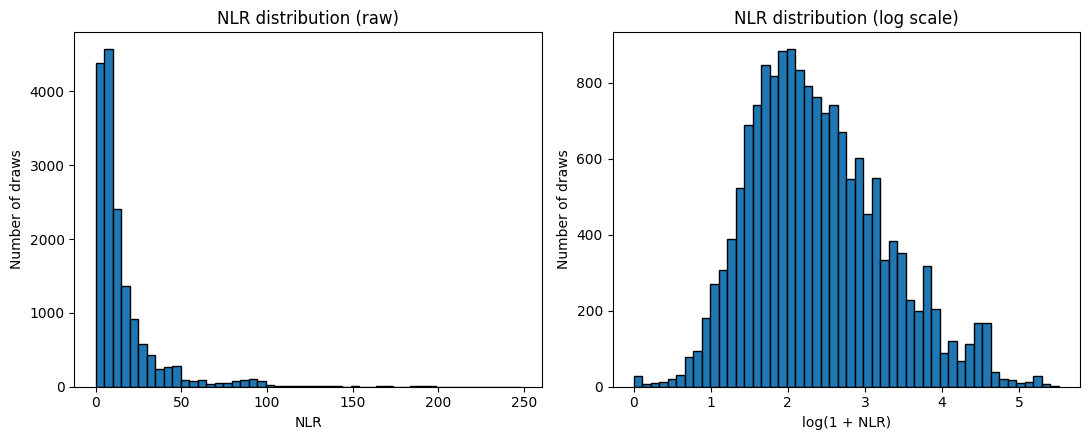

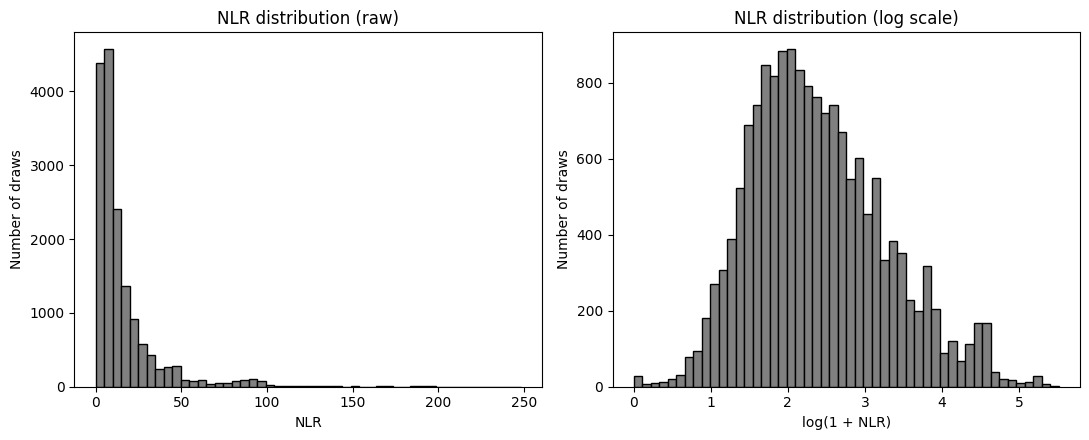

In [ ]:
# ----------------------------------------------------------------------
# 2. VISUALIZATION
# Each figure is produced twice: color version and black-and-white version
# black & white versions are for manuscript (if required)
# ----------------------------------------------------------------------

def style_bw(ax):
    """Convert a plotted axis to grayscale-friendly styling."""
    for line in ax.get_lines():
        line.set_color("black")
    for patch in ax.patches:
        patch.set_facecolor("0.6")
        patch.set_edgecolor("black")

# --- 2a. NLR distribution: raw + log scale ---
for mode, color in [("color", "tab:blue"), ("bw", "0.5")]:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].hist(df["NLR"].dropna(), bins=50, color=color, edgecolor="black")
    axes[0].set_xlabel("NLR")
    axes[0].set_ylabel("Number of draws")
    axes[0].set_title("NLR distribution (raw)")

    axes[1].hist(np.log1p(df["NLR"].dropna()), bins=50, color=color, edgecolor="black")
    axes[1].set_xlabel("log(1 + NLR)")
    axes[1].set_ylabel("Number of draws")
    axes[1].set_title("NLR distribution (log scale)")

    fig.tight_layout()
    #fig.savefig(f"fig1_NLR_distribution_{mode}.png", dpi=300)
    #plt.close(fig)

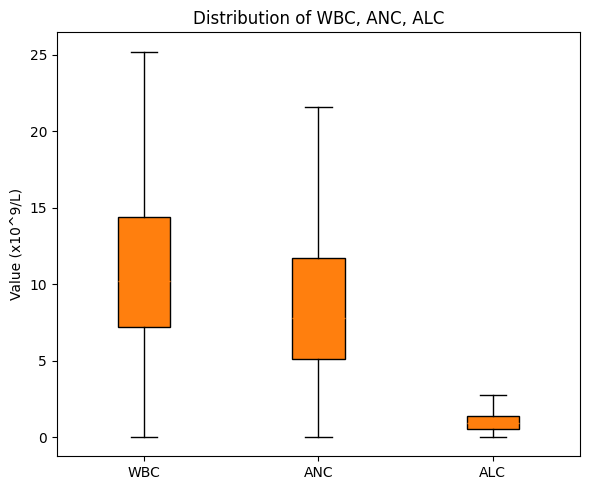

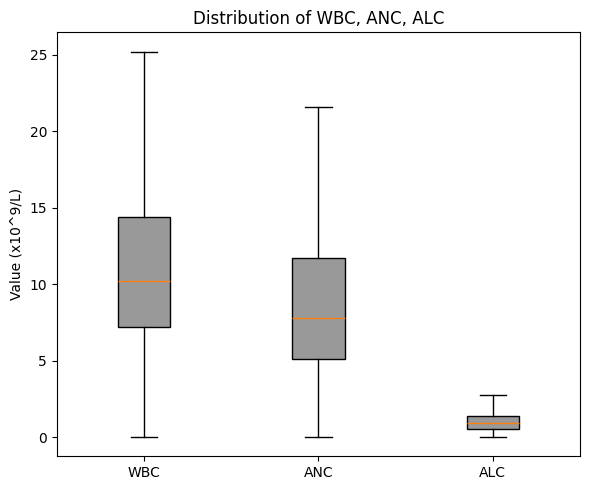

In [ ]:
# --- 2b. Boxplots of WBC / ANC / ALC ---
for mode, color in [("color", "tab:orange"), ("bw", "0.6")]:
    fig, ax = plt.subplots(figsize=(6, 5))
    data = [df["WBC"].dropna(), df["ANC"].dropna(), df["ALC"].dropna()]
    bp = ax.boxplot(data, tick_labels=["WBC", "ANC", "ALC"], patch_artist=True, showfliers=False)
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
    ax.set_ylabel("Value (x10^9/L)")
    ax.set_title("Distribution of WBC, ANC, ALC")
    fig.tight_layout()
    #fig.savefig(f"fig2_WBC_ANC_ALC_boxplot_{mode}.png", dpi=300)
    #plt.close(fig)

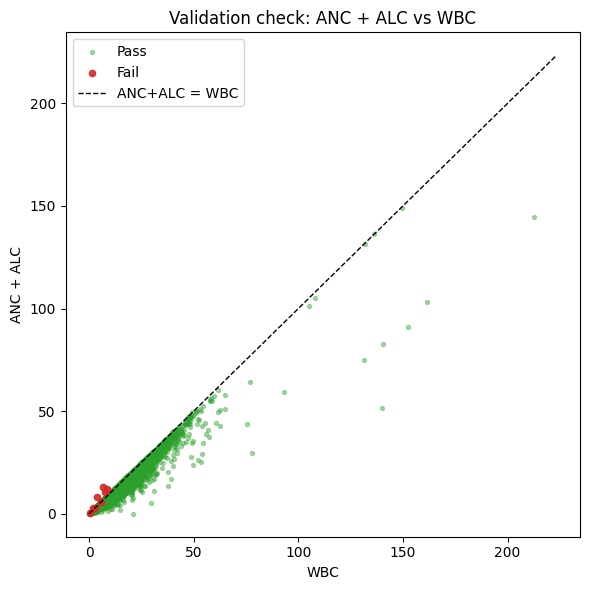

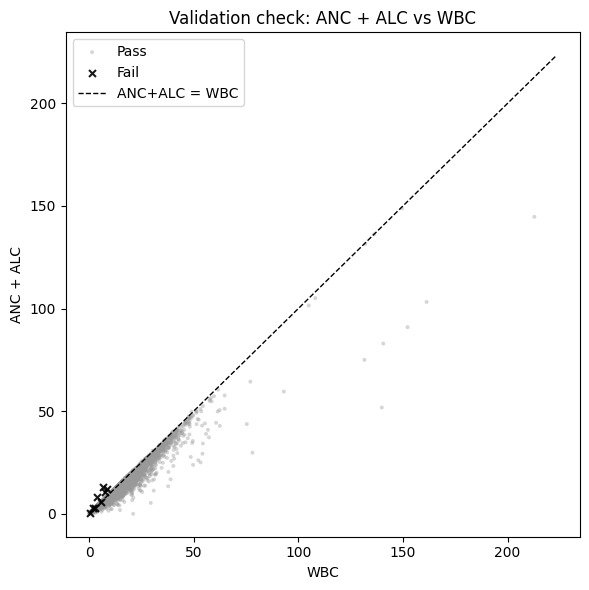

In [ ]:
# --- 2c. Validation scatter: ANC+ALC vs WBC ---
valid_df = df.dropna(subset=["WBC", "sum_ANC_ALC", "validation_pass"])
for mode in ["color", "bw"]:
    fig, ax = plt.subplots(figsize=(6, 6))
    if mode == "color":
        pass_pts = valid_df[valid_df["validation_pass"] == 1]
        fail_pts = valid_df[valid_df["validation_pass"] == 0]
        ax.scatter(pass_pts["WBC"], pass_pts["sum_ANC_ALC"], s=8, alpha=0.4,
                   color="tab:green", label="Pass")
        ax.scatter(fail_pts["WBC"], fail_pts["sum_ANC_ALC"], s=20, alpha=0.9,
                   color="tab:red", label="Fail")
    else:
        pass_pts = valid_df[valid_df["validation_pass"] == 1]
        fail_pts = valid_df[valid_df["validation_pass"] == 0]
        ax.scatter(pass_pts["WBC"], pass_pts["sum_ANC_ALC"], s=8, alpha=0.4,
                   facecolor="0.6", edgecolor="none", label="Pass")
        ax.scatter(fail_pts["WBC"], fail_pts["sum_ANC_ALC"], s=25, alpha=0.9,
                   facecolor="black", marker="x", label="Fail")
    lims = [0, valid_df["WBC"].max() * 1.05]
    ax.plot(lims, lims, linestyle="--", color="black", linewidth=1, label="ANC+ALC = WBC")
    ax.set_xlabel("WBC")
    ax.set_ylabel("ANC + ALC")
    ax.set_title("Validation check: ANC + ALC vs WBC")
    ax.legend()
    fig.tight_layout()
    #fig.savefig(f"fig3_validation_scatter_{mode}.png", dpi=300)
    #plt.close(fig)

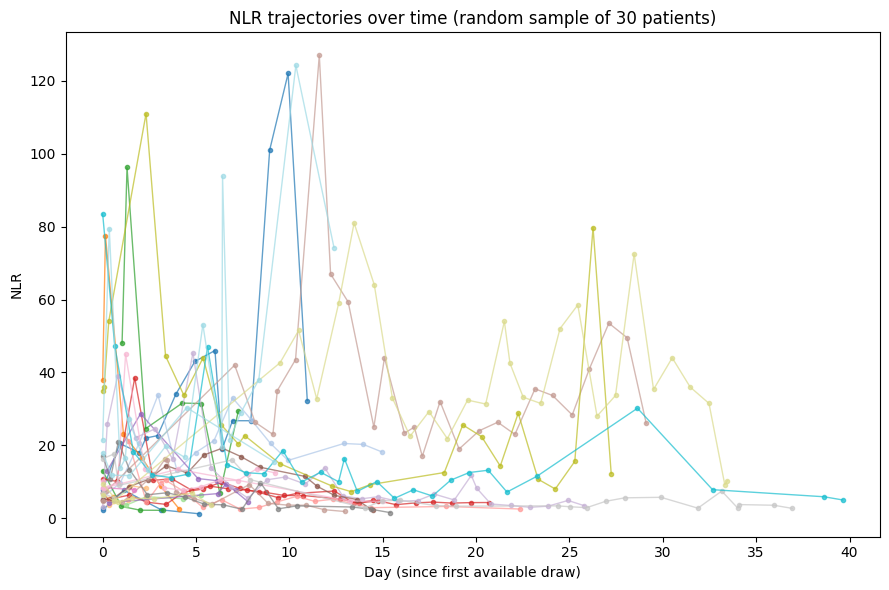

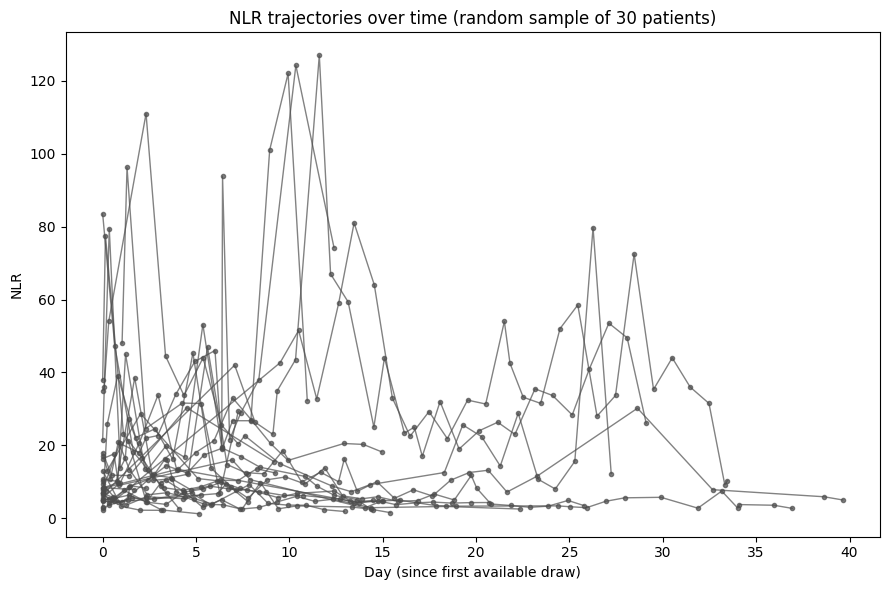

In [ ]:
# --- 2d. Spaghetti plot: NLR trajectories over time for a sample of patients ---
N_SAMPLE = 30  # number of patients to display
rng = np.random.default_rng(42)
sample_ids = rng.choice(df["SubjectID"].unique(), size=min(N_SAMPLE, n_patients), replace=False)
traj_df = df[df["SubjectID"].isin(sample_ids) & df["NLR"].notna()]

for mode in ["color", "bw"]:
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.get_cmap("tab20", len(sample_ids)) if mode == "color" else None
    for i, sid in enumerate(sample_ids):
        pt = traj_df[traj_df["SubjectID"] == sid].sort_values("day_index")
        if pt.empty:
            continue
        color = cmap(i) if mode == "color" else "0.3"
        ax.plot(pt["day_index"], pt["NLR"], marker="o", markersize=3,
                linewidth=1, alpha=0.7, color=color)
    ax.set_xlabel("Day (since first available draw)")
    ax.set_ylabel("NLR")
    ax.set_title(f"NLR trajectories over time (random sample of {len(sample_ids)} patients)")
    fig.tight_layout()
    #fig.savefig(f"fig4_NLR_trajectories_{mode}.png", dpi=300)
    #plt.close(fig)

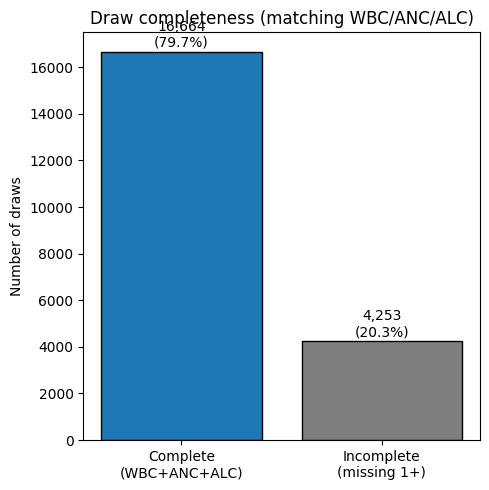

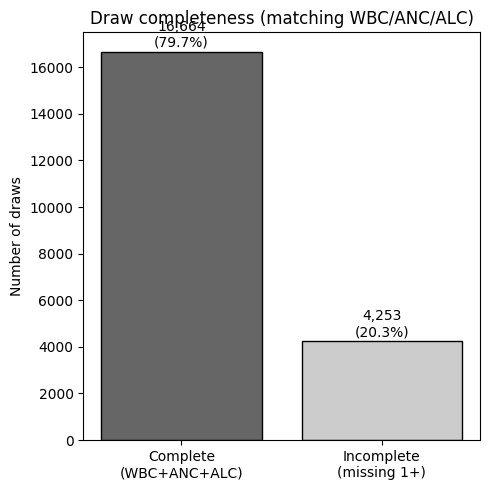

In [ ]:
# --- 2e. Match/validation rate bar chart ---
categories = ["Complete\n(WBC+ANC+ALC)", "Incomplete\n(missing 1+)"]
values = [n_complete, n_incomplete]
for mode, colors in [("color", ["tab:blue", "tab:gray"]), ("bw", ["0.4", "0.8"])]:
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.bar(categories, values, color=colors, edgecolor="black")
    for i, v in enumerate(values):
        ax.text(i, v + n_draws * 0.01, f"{v:,}\n({v/n_draws*100:.1f}%)", ha="center")
    ax.set_ylabel("Number of draws")
    ax.set_title("Draw completeness (matching WBC/ANC/ALC)")
    fig.tight_layout()
    #fig.savefig(f"fig5_completeness_bar_{mode}.png", dpi=300)
    #plt.close(fig)

# **Extra Visualization**

In [ ]:
"""
ICU CBC dataset - Supplementary visualizations
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

INPUT_PATH = "NLR_merged_validated.xlsx"

df = pd.read_excel(INPUT_PATH)
df["labdate"] = pd.to_datetime(df["labdate"])

# Day since each patient's first available draw in this dataset
df = df.sort_values(["SubjectID", "labdate"])
df["day_index"] = (
    df.groupby("SubjectID")["labdate"]
    .transform(lambda x: (x - x.min()).dt.total_seconds() / 86400)
)
df["day_round"] = df["day_index"].round().astype("Int64")

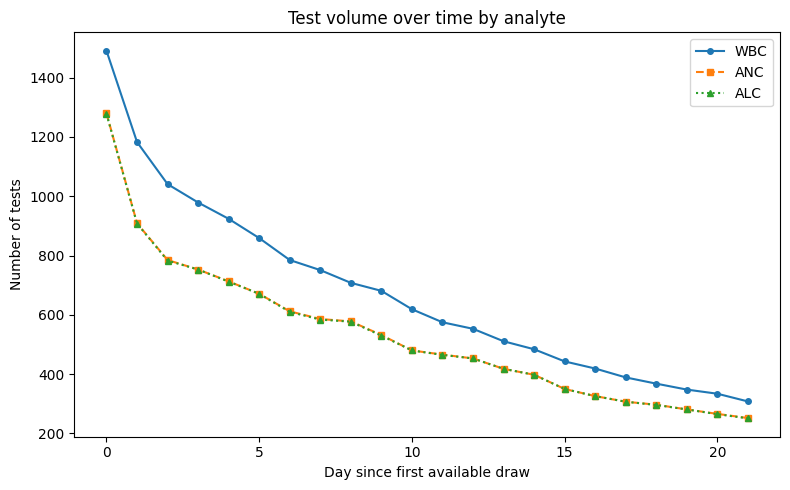

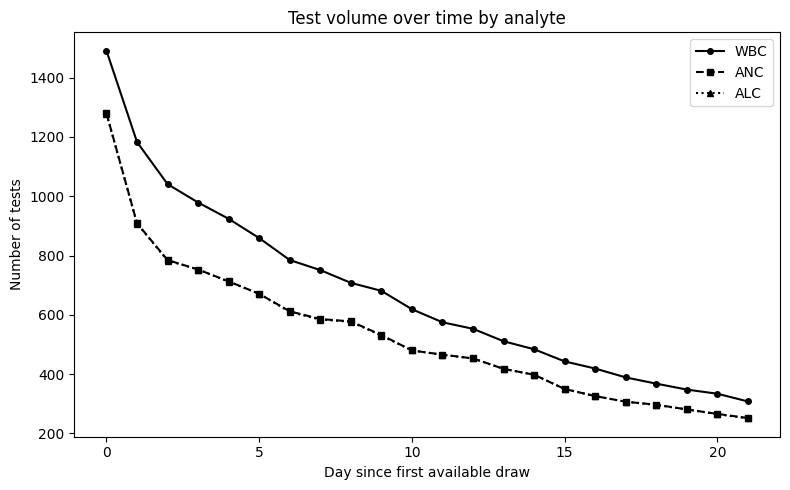

In [ ]:
# ----------------------------------------------------------------------
# PLOT 1: Test volume over time (WBC / ANC / ALC counts by day since first draw)
# ----------------------------------------------------------------------
MAX_DAY_PLOT = 21  # extend a bit past the GBTM's MAX_DAY=14 to show the falloff

counts_by_day = (
    df[df["day_round"].between(0, MAX_DAY_PLOT)]
    .melt(id_vars=["day_round"], value_vars=["WBC", "ANC", "ALC"],
          var_name="test", value_name="value")
    .dropna(subset=["value"])
    .groupby(["day_round", "test"])
    .size()
    .reset_index(name="n_tests")
)

for mode in ["color", "bw"]:
    fig, ax = plt.subplots(figsize=(8, 5))
    styles = {
        "WBC": dict(color="tab:blue" if mode == "color" else "black", linestyle="-", marker="o"),
        "ANC": dict(color="tab:orange" if mode == "color" else "black", linestyle="--", marker="s"),
        "ALC": dict(color="tab:green" if mode == "color" else "black", linestyle=":", marker="^"),
    }
    for test, style in styles.items():
        sub = counts_by_day[counts_by_day["test"] == test]
        ax.plot(sub["day_round"], sub["n_tests"], markersize=4, linewidth=1.5,
                label=test, **style)
    ax.set_xlabel("Day since first available draw")
    ax.set_ylabel("Number of tests")
    ax.set_title("Test volume over time by analyte")
    ax.legend()
    fig.tight_layout()
    #fig.savefig(f"supp_fig1_test_volume_over_time_{mode}.png", dpi=300)
    #plt.close(fig)

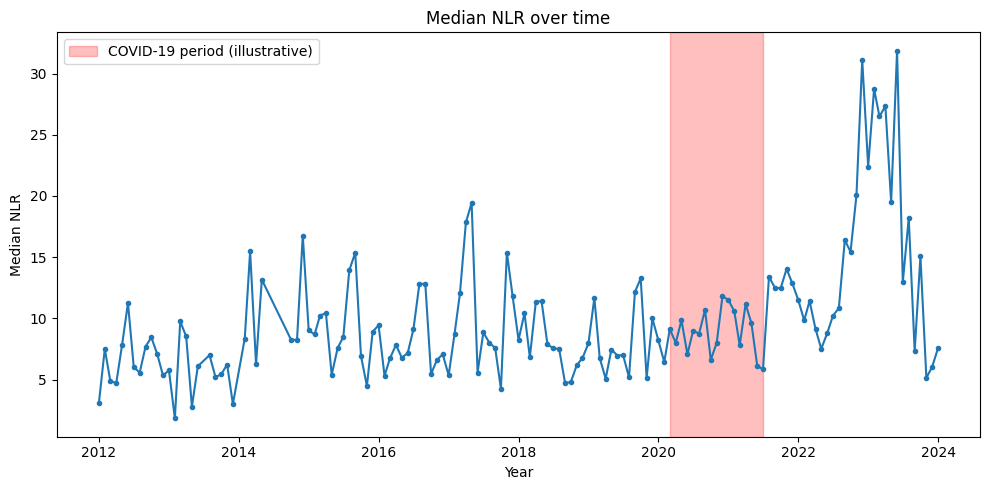

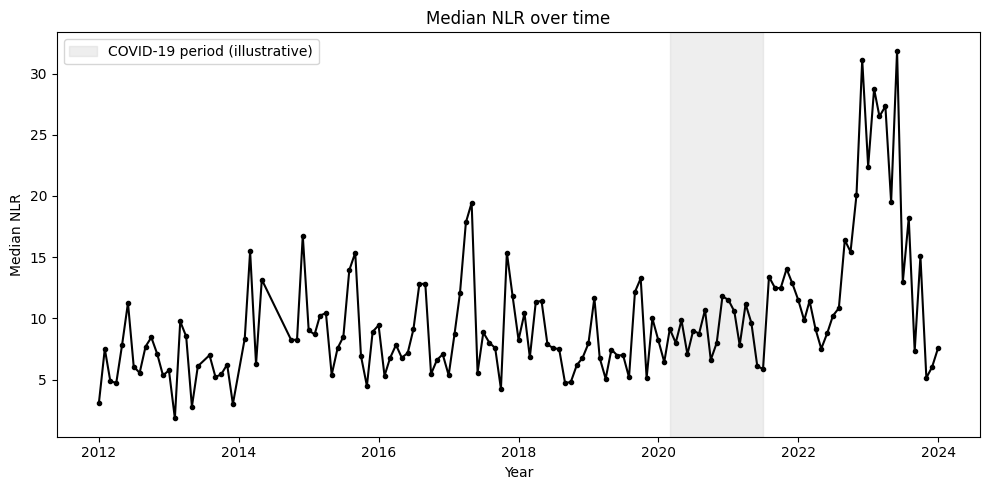

In [ ]:
# ----------------------------------------------------------------------
# PLOT 2: Average NLR over calendar time (by month), COVID period marked
# ----------------------------------------------------------------------
df["year_month"] = df["labdate"].dt.to_period("M").dt.to_timestamp()

monthly_nlr = (
    df.dropna(subset=["NLR"])
    .groupby("year_month")["NLR"]
    .median()  # median given NLR's right-skew -- more robust than mean here
    .reset_index()
)

# WHO declared COVID-19 a pandemic March 11, 2020; using a commonly-cited
# "acute pandemic period" window here for illustration

COVID_START = pd.Timestamp("2020-03-01")
COVID_END = pd.Timestamp("2021-06-30")

for mode in ["color", "bw"]:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(monthly_nlr["year_month"], monthly_nlr["NLR"],
            color="tab:blue" if mode == "color" else "black", linewidth=1.5, marker="o", markersize=3)
    ax.axvspan(COVID_START, COVID_END,
               color="red" if mode == "color" else "0.75", alpha=0.25,
               label="COVID-19 period (illustrative)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Median NLR")
    ax.set_title("Median NLR over time")
    ax.legend()
    fig.tight_layout()
    #fig.savefig(f"supp_fig2_NLR_over_time_covid_{mode}.png", dpi=300)
    #plt.close(fig)

In [ ]:
# ----------------------------------------------------------------------
# PLOT 3: Missingness heatmap by year, for WBC / ANC / ALC
# ----------------------------------------------------------------------
df["year"] = df["labdate"].dt.year

missing_by_year = (
    df.groupby("year")[["WBC", "ANC", "ALC"]]
    .apply(lambda x: x.isna().mean() * 100)
)

for mode in ["color", "bw"]:
    fig, ax = plt.subplots(figsize=(6, 8))
    cmap = "Reds" if mode == "color" else "Greys"
    im = ax.imshow(missing_by_year.values, cmap=cmap, aspect="auto", vmin=0, vmax=100)

    ax.set_xticks(range(len(missing_by_year.columns)))
    ax.set_xticklabels(missing_by_year.columns)
    ax.set_yticks(range(len(missing_by_year.index)))
    ax.set_yticklabels(missing_by_year.index)
    ax.set_xlabel("Analyte")
    ax.set_ylabel("Year")
    ax.set_title("% missing by analyte and year")

    # Annotate each cell with its percentage
    for i in range(missing_by_year.shape[0]):
        for j in range(missing_by_year.shape[1]):
            val = missing_by_year.values[i, j]
            text_color = "white" if val > 50 else "black"
            ax.text(j, i, f"{val:.1f}%", ha="center", va="center", color=text_color, fontsize=8)

    fig.colorbar(im, ax=ax, label="% missing")
    fig.tight_layout()
    fig.savefig(f"supp_fig3_missingness_heatmap_{mode}.png", dpi=300)
    plt.close(fig)

print("Saved supplementary figures:")
print(" supp_fig1_test_volume_over_time / supp_fig2_NLR_over_time_covid / supp_fig3_missingness_heatmap")
print("\nOverall % missing by analyte (for reference):")
print((df[["WBC", "ANC", "ALC"]].isna().mean() * 100).round(1))

Saved supplementary figures:
 supp_fig1_test_volume_over_time / supp_fig2_NLR_over_time_covid / supp_fig3_missingness_heatmap

Overall % missing by analyte (for reference):
WBC     0.0
ANC    20.1
ALC    20.3
dtype: float64


# **Data Filter - Flow Diagram**

In [ ]:
pip install graphviz

In [ ]:
from graphviz import Digraph

# Initialize a directed graph
dot = Digraph('NLR_Filtering', format='png')
dot.attr(rankdir='TB', splines='ortho')

# Set default styles for nodes
dot.attr('node', shape='box', style='rounded,filled', fontname='Helvetica')

# 1. Processing Steps (Gray)
dot.attr('node', fillcolor='#E0E0E0', color='black')
dot.node('raw', 'Raw lab result records\n65,139 rows, 907 patients')
dot.node('dedup', 'Deduplicated records\n55,853 rows remain')
dot.node('one_row', 'One row per blood draw\n20,917 draws (reshaped)')
dot.node('complete', 'Complete draws\n16,664 draws (79.7%)', fillcolor='#D1E7E0')
dot.node('validated', 'Validated draws\n16,656 draws', fillcolor='#D1E7E0')
dot.node('final', 'Final analytic sample\n16,383 draws with NLR (78.3%)', fillcolor='#C8E6C9')

# 2. Exclusion Boxes (Coral)
dot.attr('node', fillcolor='#F8D7DA', color='#B27D7D', fontcolor='#842029')
dot.node('ex1', '1,881 rows\nnon-numeric flag, set to missing')
dot.node('ex2', '9,286 rows\nexact duplicates removed')
dot.node('ex3', '4,253 draws\nincomplete, excluded')
dot.node('ex4', '8 draws\nfailed validation')
dot.node('ex5', '273 draws\nmissing / zero ALC')

# 3. Create Connections
# Main flow
dot.edge('raw', 'dedup')
dot.edge('dedup', 'one_row')
dot.edge('one_row', 'complete')
dot.edge('complete', 'validated')
dot.edge('validated', 'final')

# Connect exclusions (using invisible edges or styles to match your layout)
dot.edge('raw', 'ex1', style='dashed', dir='none')
dot.edge('raw', 'ex2', style='dashed', dir='none')
dot.edge('one_row', 'ex3', style='dashed', dir='none')
dot.edge('complete', 'ex4', style='dashed', dir='none')
dot.edge('validated', 'ex5', style='dashed', dir='none')

# Render the graph
dot.render('nlr_flowchart', view=True)

'nlr_flowchart.png'

In [ ]:
#Updated Flow Chart

from graphviz import Digraph

# Initialize a directed graph
dot = Digraph('NLR_Filtering', format='png')
dot.attr(rankdir='TB', splines='ortho')

# Set default styles for nodes
dot.attr('node', shape='box', style='rounded,filled', fontname='Helvetica')

# 1. Processing Steps (Gray)
dot.attr('node', fillcolor='#E0E0E0', color='black')
dot.node('raw', 'Raw lab result records\n65,139 rows, 907 patients')
dot.node('dedup', 'Deduplicated records\n55,853 rows remain')
dot.node('one_row', 'One row per blood draw\n20,917 draws (reshaped)')
dot.node('complete', 'Complete draws\n16,664 draws (79.7%)', fillcolor='#D1E7E0')
dot.node('validated', 'Validated draws\n16,656 draws', fillcolor='#D1E7E0')
dot.node('final', 'Final analytic sample\n16,383 draws with NLR (78.3%)', fillcolor='#C8E6C9')

# 2. Exclusion Boxes (Coral)
dot.attr('node', fillcolor='#F8D7DA', color='#B27D7D', fontcolor='#842029')
#dot.node('ex1', '1,881 rows\nnon-numeric flag, set to missing')
dot.node('ex2', '9,286 rows\nexact duplicates and non-numeric values removed')
dot.node('ex3', '4,253 draws\nincomplete, excluded')
dot.node('ex4', '8 draws\nfailed validation')
dot.node('ex5', '273 draws removed\n zero ALC')

# 3. Create Connections
# Main flow
dot.edge('raw', 'dedup')
dot.edge('dedup', 'one_row')
dot.edge('one_row', 'complete')
dot.edge('complete', 'validated')
dot.edge('validated', 'final')

# Connect exclusions (using invisible edges or styles to match your layout)
#dot.edge('raw', 'ex1', style='dashed', dir='none')
dot.edge('raw', 'ex2', style='dashed', dir='none')
dot.edge('one_row', 'ex3', style='dashed', dir='none')
dot.edge('complete', 'ex4', style='dashed', dir='none')
dot.edge('validated', 'ex5', style='dashed', dir='none')

# Render the graph
dot.render('nlr_flowchart_updated', view=True)

'nlr_flowchart_updated.png'

# **Additional Visualization**

In [ ]:
"""
ICU CBC dataset - Highest/lowest NLR exploration

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

INPUT_PATH = "NLR_merged_validated.xlsx"

df = pd.read_excel(INPUT_PATH)
df["labdate"] = pd.to_datetime(df["labdate"])
df = df.sort_values(["SubjectID", "labdate"])
df["day_index"] = (
    df.groupby("SubjectID")["labdate"]
    .transform(lambda x: (x - x.min()).dt.total_seconds() / 86400)
)

Highest median NLR: 2023-06 (median=31.87, n=119 draws)
Lowest median NLR:  2013-02 (median=1.83, n=32 draws)


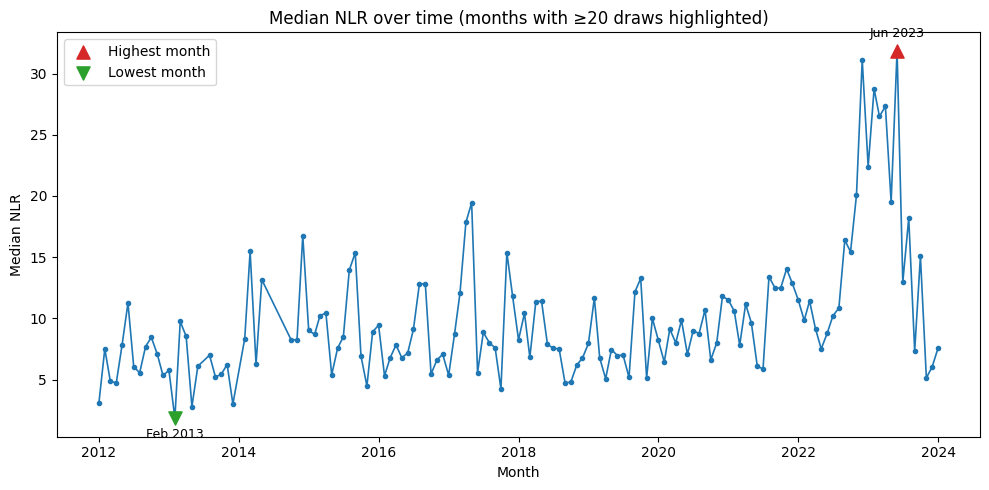

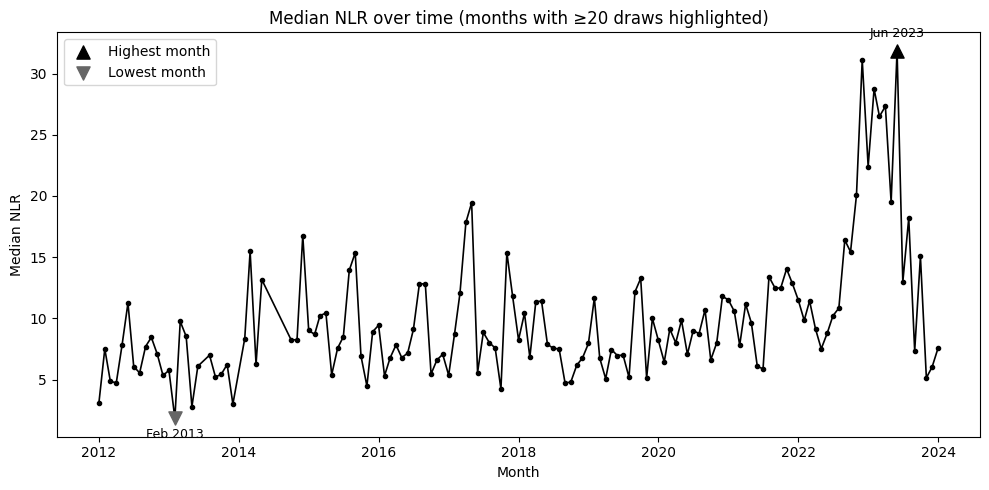

In [ ]:
# ----------------------------------------------------------------------
# PLOT A: Monthly median NLR, with the highest and lowest months marked
# ----------------------------------------------------------------------
df["year_month"] = df["labdate"].dt.to_period("M").dt.to_timestamp()
monthly_nlr = (
    df.dropna(subset=["NLR"])
    .groupby("year_month")["NLR"]
    .agg(median_NLR="median", n="count")
    .reset_index()
)

# Restrict to months with a reasonable number of draws so a single outlier
# month (e.g. only 1-2 draws) doesn't dominate the "highest/lowest" label
MIN_DRAWS_PER_MONTH = 20
stable_months = monthly_nlr[monthly_nlr["n"] >= MIN_DRAWS_PER_MONTH]

highest_month = stable_months.loc[stable_months["median_NLR"].idxmax()]
lowest_month = stable_months.loc[stable_months["median_NLR"].idxmin()]

print(f"Highest median NLR: {highest_month['year_month'].strftime('%Y-%m')} "
      f"(median={highest_month['median_NLR']:.2f}, n={highest_month['n']:.0f} draws)")
print(f"Lowest median NLR:  {lowest_month['year_month'].strftime('%Y-%m')} "
      f"(median={lowest_month['median_NLR']:.2f}, n={lowest_month['n']:.0f} draws)")

for mode in ["color", "bw"]:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(monthly_nlr["year_month"], monthly_nlr["median_NLR"],
            color="tab:blue" if mode == "color" else "black", linewidth=1.2, marker="o", markersize=3)

    high_color = "tab:red" if mode == "color" else "black"
    low_color = "tab:green" if mode == "color" else "0.4"
    ax.scatter([highest_month["year_month"]], [highest_month["median_NLR"]],
               color=high_color, s=90, zorder=5, marker="^", label="Highest month")
    ax.scatter([lowest_month["year_month"]], [lowest_month["median_NLR"]],
               color=low_color, s=90, zorder=5, marker="v", label="Lowest month")

    ax.annotate(highest_month["year_month"].strftime("%b %Y"),
                (highest_month["year_month"], highest_month["median_NLR"]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
    ax.annotate(lowest_month["year_month"].strftime("%b %Y"),
                (lowest_month["year_month"], lowest_month["median_NLR"]),
                textcoords="offset points", xytext=(0, -14), ha="center", fontsize=9)

    ax.set_xlabel("Month")
    ax.set_ylabel("Median NLR")
    ax.set_title(f"Median NLR over time (months with \u2265{MIN_DRAWS_PER_MONTH} draws highlighted)")
    ax.legend()
    fig.tight_layout()
    #fig.savefig(f"supp_fig_NLR_highlow_month_{mode}.png", dpi=300)
    #plt.close(fig)

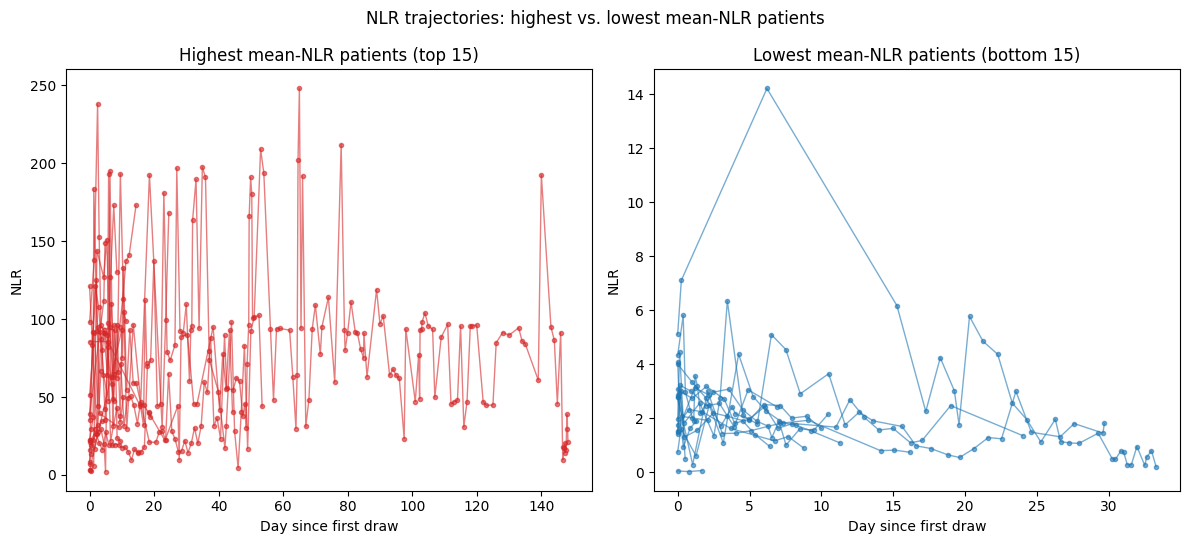

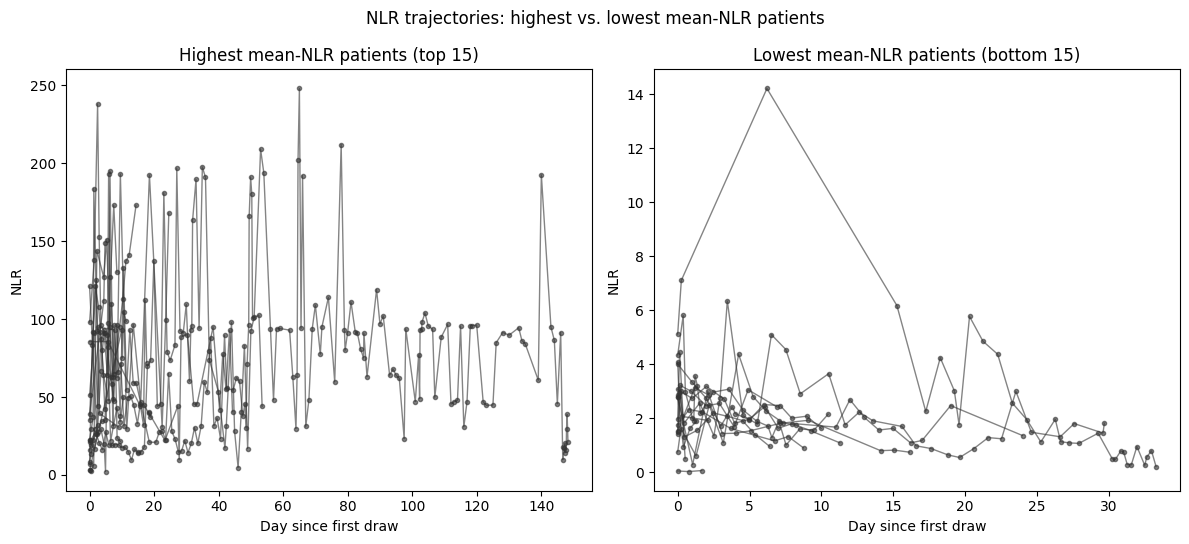

In [ ]:
# ----------------------------------------------------------------------
# PLOT B: NLR trajectories for the highest-NLR vs lowest-NLR patients
# Selection based on each patient's MEAN NLR (more stable than a single peak)
# ----------------------------------------------------------------------
N_PATIENTS = 15  # per group
MIN_DRAWS_PER_PATIENT = 3  # require a real trajectory, not a single point

patient_mean_nlr = (
    df.dropna(subset=["NLR"])
    .groupby("SubjectID")
    .agg(mean_NLR=("NLR", "mean"), n_draws=("NLR", "count"))
    .reset_index()
)
eligible = patient_mean_nlr[patient_mean_nlr["n_draws"] >= MIN_DRAWS_PER_PATIENT]

highest_patients = eligible.nlargest(N_PATIENTS, "mean_NLR")["SubjectID"]
lowest_patients = eligible.nsmallest(N_PATIENTS, "mean_NLR")["SubjectID"]

for mode in ["color", "bw"]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=False)

    high_color = "tab:red" if mode == "color" else "0.2"
    low_color = "tab:blue" if mode == "color" else "0.2"

    for sid in highest_patients:
        pt = df[(df["SubjectID"] == sid) & df["NLR"].notna()].sort_values("day_index")
        axes[0].plot(pt["day_index"], pt["NLR"], marker="o", markersize=3,
                     linewidth=1, alpha=0.6, color=high_color)
    axes[0].set_title(f"Highest mean-NLR patients (top {N_PATIENTS})")
    axes[0].set_xlabel("Day since first draw")
    axes[0].set_ylabel("NLR")

    for sid in lowest_patients:
        pt = df[(df["SubjectID"] == sid) & df["NLR"].notna()].sort_values("day_index")
        axes[1].plot(pt["day_index"], pt["NLR"], marker="o", markersize=3,
                     linewidth=1, alpha=0.6, color=low_color)
    axes[1].set_title(f"Lowest mean-NLR patients (bottom {N_PATIENTS})")
    axes[1].set_xlabel("Day since first draw")
    axes[1].set_ylabel("NLR")

    fig.suptitle("NLR trajectories: highest vs. lowest mean-NLR patients")
    fig.tight_layout()
    #fig.savefig(f"supp_fig_NLR_trajectories_highlow_{mode}.png", dpi=300)
    #plt.close(fig)

# **GBTM Visualization**

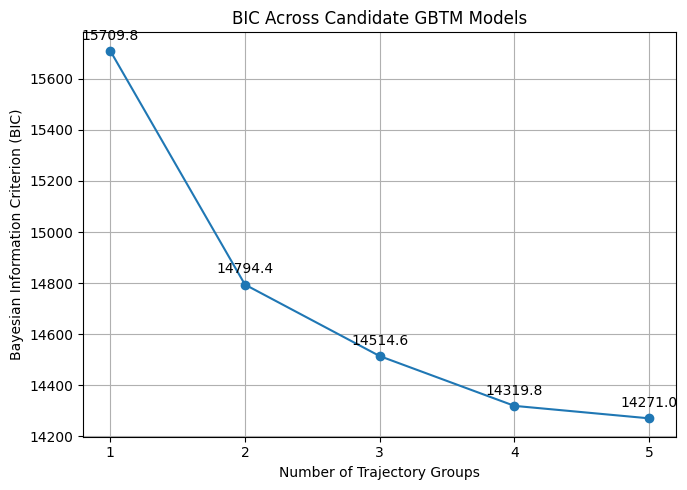

In [ ]:
import matplotlib.pyplot as plt

#-----------------------------
# Data
#-----------------------------

groups = [1,2,3,4,5]

bic = [
    15709.78,
    14794.41,
    14514.62,
    14319.76,
    14270.95
]

#-----------------------------
# Plot
#-----------------------------

fig, ax = plt.subplots(figsize=(7,5))

ax.plot(
    groups,
    bic,
    marker="o"
)

# annotate values
for x, y in zip(groups, bic):
    ax.annotate(
        f"{y:.1f}",
        (x, y),
        textcoords="offset points",
        xytext=(0,8),
        ha="center"
    )

ax.set_xlabel("Number of Trajectory Groups")
ax.set_ylabel("Bayesian Information Criterion (BIC)")
ax.set_title("BIC Across Candidate GBTM Models")

ax.set_xticks(groups)

ax.grid(True)

plt.tight_layout()
plt.show()

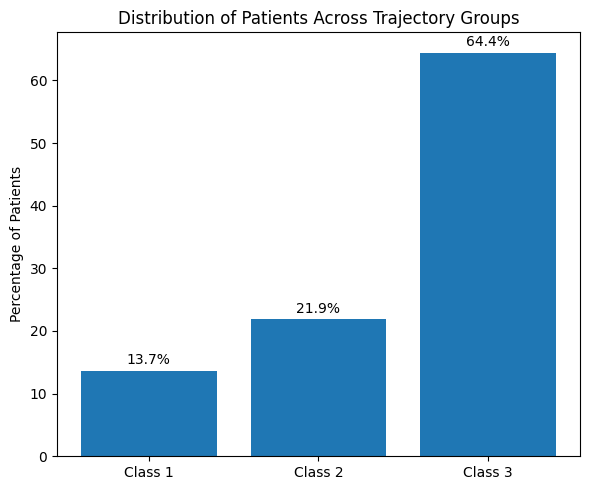

In [ ]:
import matplotlib.pyplot as plt

classes=["Class 1","Class 2","Class 3"]

percentages=[
13.674,
21.879,
64.447
]

plt.figure(figsize=(6,5))

bars=plt.bar(classes,percentages)

for bar,p in zip(bars,percentages):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        p+1,
        f"{p:.1f}%",
        ha="center"
    )

plt.ylabel("Percentage of Patients")
plt.title("Distribution of Patients Across Trajectory Groups")

plt.tight_layout()
plt.show()

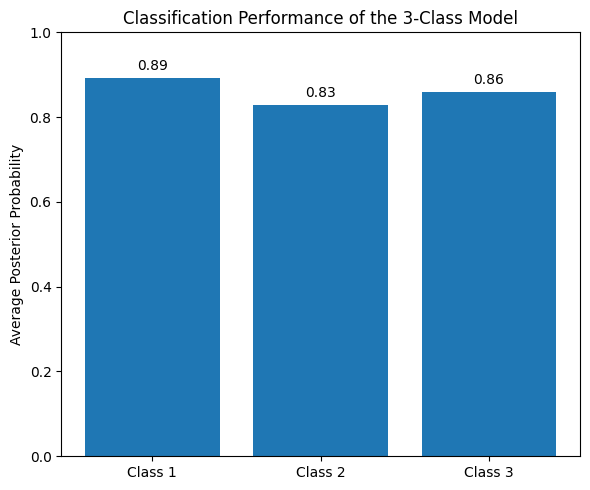

In [ ]:
import matplotlib.pyplot as plt

classes=[
"Class 1",
"Class 2",
"Class 3"
]

probabilities=[
0.8923,
0.8286,
0.8593
]

plt.figure(figsize=(6,5))

bars=plt.bar(classes,probabilities)

for bar,p in zip(bars,probabilities):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        p+0.02,
        f"{p:.2f}",
        ha="center"
    )

plt.ylim(0,1)

plt.ylabel("Average Posterior Probability")
plt.title("Classification Performance of the 3-Class Model")

plt.tight_layout()
plt.show()